<a href="https://colab.research.google.com/github/Jagdeep-879/Financial_Analytics/blob/main/Fraudulent_detection_using_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fraud Detection Analysis Workflow

The primary goal is to accurately detect fraudulent transactions while minimizing false negatives, which are crucial in fraud detection to avoid missing actual fraudulent activities.

We will cover the following key steps:

1.  **Data Loading**: Load the credit card transaction data.
2.  **Exploratory Data Analysis (EDA)**: Understand the dataset's characteristics, identify data types, check for missing values, and analyze the distribution of fraudulent vs. non-fraudulent transactions.
3.  **Data Preprocessing**: Handle missing values, encode categorical features, scale numerical features, and address the class imbalance.
4.  **Model Selection**: Choose appropriate machine learning models for binary classification.
5.  **Model Training**: Train the selected models on the preprocessed data.
6.  **Model Evaluation**: Evaluate model performance using relevant metrics (e.g., precision, recall, F1-score, ROC-AUC), with a particular focus on recall to minimize false negatives.
7.  **Interpretation and Conclusion**: Analyze model results and draw conclusions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/content/creditcard.csv')

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


### Explanation of Principal Component Features (V1-V28)

The features `V1` through `V28` are the result of applying **Principal Component Analysis (PCA)** to the original, confidential features of the dataset. Here's a breakdown of what that means:

*   **What is PCA?**
    PCA is a statistical procedure that uses an orthogonal transformation to convert a set of observations of possibly correlated variables into a set of values of linearly uncorrelated variables called principal components. This transformation is defined in such a way that the first principal component has the largest possible variance (that is, accounts for as much of the variability in the data as possible), and each succeeding component in turn has the highest variance possible under the constraint that it is orthogonal to the preceding components.

*   **Why is PCA used here?**
    1.  **Confidentiality**: In many real-world datasets, especially those involving sensitive financial information, the original features (e.g., specific transaction details like merchant ID, card type, exact location) are kept confidential to protect privacy. PCA allows the underlying patterns and information to be retained while masking the original data.
    2.  **Dimensionality Reduction**: By transforming a potentially large number of original features into a smaller set of principal components, PCA can reduce the complexity of the data, making it easier and faster for machine learning models to process.
    3.  **Noise Reduction**: PCA can help in removing noise from the data by focusing on the components that capture the most significant variance.
    4.  **Multicollinearity**: It addresses multicollinearity (high correlation between features) by creating uncorrelated principal components.

*   **Interpretation of V1-V28**
    *   **Abstract Nature**: Unlike original features, which often have direct, intuitive meanings (e.g., 'age', 'salary', 'transaction type'), principal components like `V1`, `V2`, etc., are abstract. Each `V` feature is a linear combination of the original features.
    *   **Orthogonality**: These components are statistically uncorrelated (orthogonal), meaning each one captures a unique dimension of variance in the data that is not explained by the others.
    *   **Contribution to Variance**: `V1` explains the most variance, `V2` the second most, and so on. However, without knowing the coefficients of the linear combinations, it's impossible to know what specific original features contribute to each principal component.

In the context of this fraud detection dataset, the V-features provide the necessary information for a model to distinguish between fraudulent and non-fraudulent transactions without revealing the sensitive details of the original data.

In [ ]:
df.shape


(281167, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 281167 entries, 0 to 281166
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    281167 non-null  float64
 1   V1      281167 non-null  float64
 2   V2      281167 non-null  float64
 3   V3      281167 non-null  float64
 4   V4      281167 non-null  float64
 5   V5      281167 non-null  float64
 6   V6      281167 non-null  float64
 7   V7      281167 non-null  float64
 8   V8      281167 non-null  float64
 9   V9      281167 non-null  float64
 10  V10     281167 non-null  float64
 11  V11     281167 non-null  float64
 12  V12     281167 non-null  float64
 13  V13     281167 non-null  float64
 14  V14     281167 non-null  float64
 15  V15     281167 non-null  float64
 16  V16     281167 non-null  float64
 17  V17     281167 non-null  float64
 18  V18     281167 non-null  float64
 19  V19     281167 non-null  float64
 20  V20     281167 non-null  float64
 21  V21     28

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,281167.000000,281167.000000,281167.000000,281167.000000,281167.000000,281167.000000,281167.000000,281167.000000,281167.000000,281167.000000,...,281167.000000,281167.000000,281166.000000,281166.000000,281166.000000,281166.000000,281166.000000,281166.000000,281166.000000,281166.000000
mean,93823.473036,-0.000490,-0.004829,0.010208,0.001872,-0.003643,0.001853,-0.001489,-0.000453,-0.000139,...,-0.000152,-0.001122,-0.000658,-0.000287,0.001808,0.000052,-0.000026,-0.000007,88.636666,0.001746
std,46984.722160,1.956923,1.651050,1.513663,1.415779,1.378519,1.330868,1.234843,1.191939,1.099999,...,0.735420,0.724604,0.626269,0.605912,0.520640,0.482668,0.403576,0.330547,250.199065,0.041752
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,53806.000000,-0.920419,-0.601691,-0.876622,-0.848351,-0.695718,-0.766271,-0.555334,-0.207747,-0.644757,...,-0.228028,-0.541219,-0.162176,-0.354603,-0.314985,-0.327427,-0.070751,-0.052754,5.690000,0.000000
50%,83803.000000,0.019150,0.063320,0.191483,-0.016544,-0.059012,-0.271461,0.037916,0.022928,-0.052296,...,-0.029718,0.005952,-0.011750,0.041260,0.019832,-0.052788,0.001464,0.011488,22.080000,0.000000
75%,138161.000000,1.311918,0.799451,1.034872,0.748386,0.607208,0.400851,0.567684,0.327050,0.598312,...,0.185190,0.525308,0.146637,0.438420,0.351927,0.241803,0.090713,0.078110,77.740000,0.000000
max,169979.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [ ]:
class_distribution=df['Class'].value_counts()
#% fradulent in training dataset
fraud_percentage=class_distribution[1]/class_distribution.sum()*100
print(f'Fraud Percentage: {fraud_percentage:.2f}%')


Fraud Percentage: 0.17%


Low fraud percentage indicates High Imbalanced datset. We will handle it using SMOTE(oversampling) later.

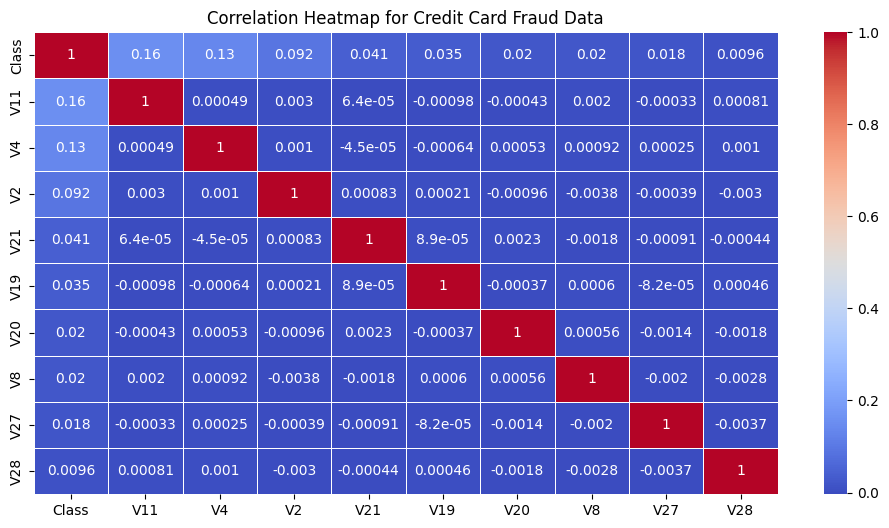

In [ ]:
# correlation matrix to see top 10 features affect in the target(Class)

top_corr = df.corr()['Class'].sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.heatmap(df[top_corr.index].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap for Credit Card Fraud Data')
plt.show()

### Feature Description

*   **`Time`**: This feature represents the time elapsed in seconds between this transaction and the first transaction in the dataset. It has been normalized to a range of (-1, 1).
*   **`V1-V28`**: These are principal components obtained from a PCA transformation. Due to confidentiality, the original features are not provided.
*   **`Amount`**: The transaction amount. This feature has also been normalized to a range of (-1, 1).
*   **`Class`**: The target variable, indicating whether a transaction is fraudulent (`1`) or non-fraudulent (`0`).

### Statistical Summary

Here's a brief overview of the statistical properties for key columns:

*   **`Time`**: Ranges from 0 to 169,979 seconds, with a mean of approximately 93,823 seconds.
*   **`Amount`**: Varies significantly, with a minimum of 0.0 and a maximum of 25,691.16. The mean amount is around 88.64, indicating that most transactions are relatively small.
*   **`Class`**: The mean of 0.001746 highlights the severe class imbalance, with only about 0.17% of transactions being fraudulent. The min is 0.0 and the max is 1.0, as expected for a binary classification target.

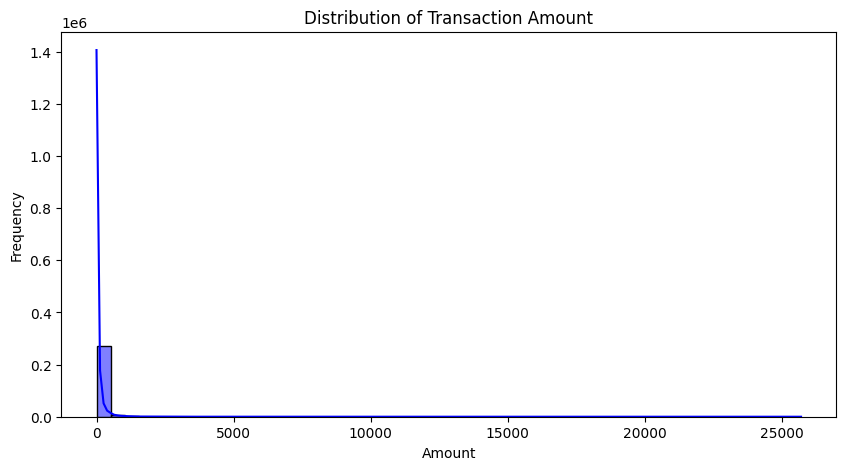

/tmp/ipykernel_11607/3056566716.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y=feature, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_11607/3056566716.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y=feature, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_11607/3056566716.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y=feature, data=df, ax=axes[i], palette='Set2')


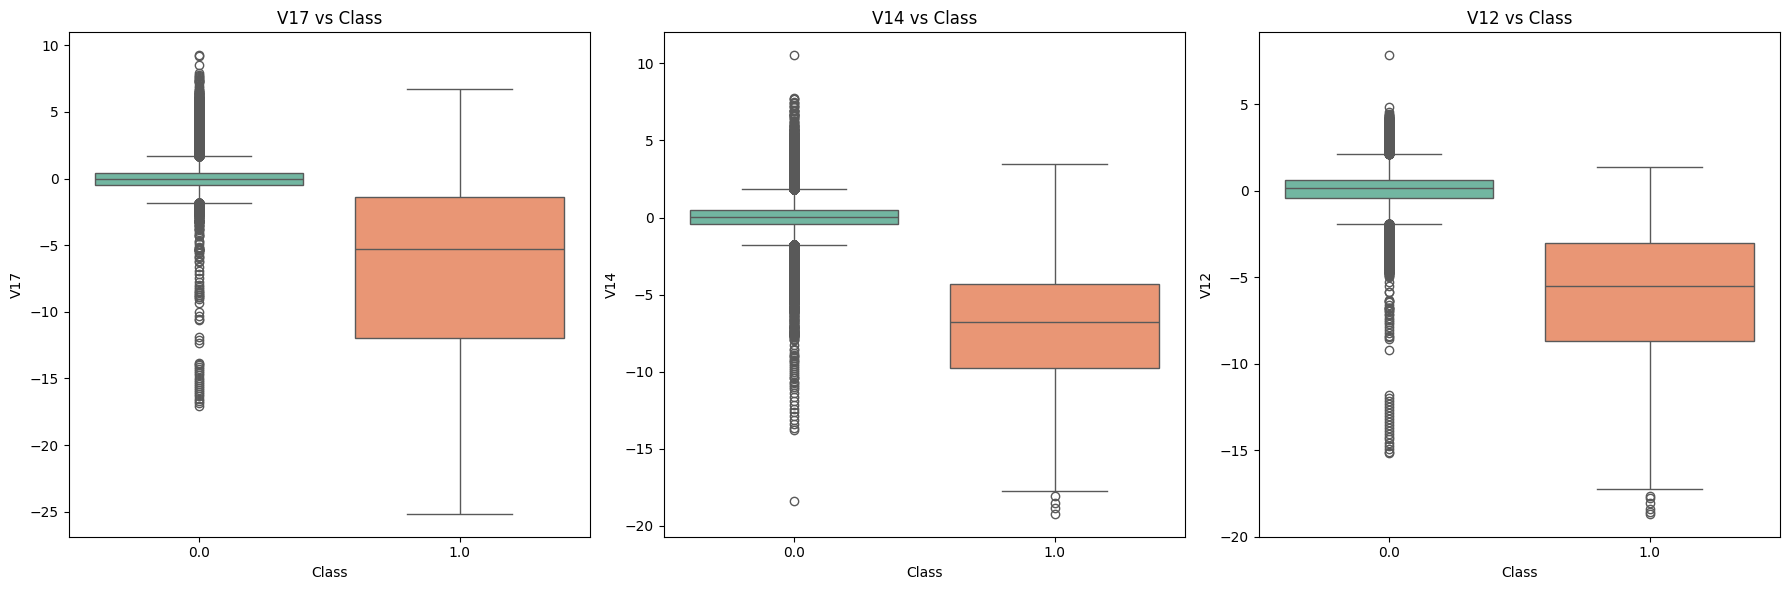

In [ ]:
# This helps in identifying if we need Scaling or if there are outliers in transaction values
plt.figure(figsize=(10, 5))
sns.histplot(df['Amount'], bins=50, kde=True, color='blue')
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

# 2. Compare Class distributions for key features using Boxplots
# We select V17, V14, and V12 because they usually have strong correlations with Fraud
features_to_plot = ['V17', 'V14', 'V12']
fig, axes = plt.subplots(ncols=len(features_to_plot), figsize=(18, 6))

for i, feature in enumerate(features_to_plot):
    sns.boxplot(x="Class", y=feature, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feature} vs Class')

plt.tight_layout()
plt.show()

Due to skewness of amount  we need to normalize the amount from (-1,1)

In [ ]:
#Normalization of amount and date-time
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.000000,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,-0.988352,0.0
1,-1.000000,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.999791,0.0
2,-0.999988,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,-0.970522,0.0
3,-0.999988,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,-0.990386,0.0
4,-0.999976,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.994551,0.0


### Handling Missing Values

Based on the `df.isnull().sum()` output, there is one row with missing values in several columns. Since the number of missing values is very small (only 1 row out of 79318), and it affects critical columns including the target variable `Class`, the most straightforward approach is to drop these rows. This ensures that we work with a complete and clean dataset for modeling.

In [ ]:
df.dropna(inplace=True)
print('Shape of dataframe after dropping null values:', df.shape)
df.info()

Shape of dataframe after dropping null values: (281166, 31)
<class 'pandas.core.frame.DataFrame'>
Index: 281166 entries, 0 to 281165
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    281166 non-null  float64
 1   V1      281166 non-null  float64
 2   V2      281166 non-null  float64
 3   V3      281166 non-null  float64
 4   V4      281166 non-null  float64
 5   V5      281166 non-null  float64
 6   V6      281166 non-null  float64
 7   V7      281166 non-null  float64
 8   V8      281166 non-null  float64
 9   V9      281166 non-null  float64
 10  V10     281166 non-null  float64
 11  V11     281166 non-null  float64
 12  V12     281166 non-null  float64
 13  V13     281166 non-null  float64
 14  V14     281166 non-null  float64
 15  V15     281166 non-null  float64
 16  V16     281166 non-null  float64
 17  V17     281166 non-null  float64
 18  V18     281166 non-null  float64
 19  V19     281166 non-null  float6

## Dataset Description

The dataset contains credit card transaction data, where each row represents a transaction. It includes the following key characteristics:

### Shape of the Dataset
*   **Rows**: 281,166 transactions
*   **Columns**: 31 features

### Data Types
All features (`Time`, `V1` through `V28`, `Amount`, `Class`) are of `float64` type.

### Missing Values
Initially, one row contained missing values across several columns (V23, V24, V25, V26, V27, V28, Amount, Class). These rows have been dropped, resulting in a clean dataset with no missing values.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')
print('\nClass distribution in original dataset:\n', y.value_counts(normalize=True))
print('\nClass distribution in y_train:\n', y_train.value_counts(normalize=True))
print('\nClass distribution in y_test:\n', y_test.value_counts(normalize=True))

X_train shape: (224932, 30)
X_test shape: (56234, 30)
y_train shape: (224932,)
y_test shape: (56234,)

Class distribution in original dataset:
 Class
0.0    0.998254
1.0    0.001746
Name: proportion, dtype: float64

Class distribution in y_train:
 Class
0.0    0.998253
1.0    0.001747
Name: proportion, dtype: float64

Class distribution in y_test:
 Class
0.0    0.998257
1.0    0.001743
Name: proportion, dtype: float64


### Separate Fraud and Non-Fraud Classes and Randomize

Given the high class imbalance, it's often beneficial to separate the fraudulent and non-fraudulent transactions in the training set for further processing, such as applying sampling techniques (e.g., undersampling the majority class or oversampling the minority class). After separation, we'll randomize the order of the samples within each class.

In [ ]:
# Separate the dataframes for fraud and non-fraud classes from the training set
fraud_df = X_train[y_train == 1].copy()
non_fraud_df = X_train[y_train == 0].copy()

# Randomize the rows within each dataframe
fraud_df = fraud_df.sample(frac=1, random_state=42).reset_index(drop=True)
non_fraud_df = non_fraud_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Shape of fraudulent transactions in training set: {fraud_df.shape}')
print(f'Shape of non-fraudulent transactions in training set: {non_fraud_df.shape}')

print('\nFirst 5 rows of randomized fraudulent transactions:')
display(fraud_df.head())

print('\nFirst 5 rows of randomized non-fraudulent transactions:')
display(non_fraud_df.head())

Shape of fraudulent transactions in training set: (393, 30)
Shape of non-fraudulent transactions in training set: (224539, 30)

First 5 rows of randomized fraudulent transactions:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.753723,-16.367923,9.223692,-23.270631,11.844777,-9.462037,-2.450444,-16.925152,1.384208,-6.287736,...,0.993585,-2.343674,1.004602,1.188212,-1.047184,-0.035573,0.664900,2.122796,-1.416741,-0.999922
1,-0.494232,-4.075975,0.963031,-5.076070,4.955963,-0.161437,-2.832663,-7.619765,1.618895,-2.992092,...,0.058861,1.030738,0.165328,-1.017502,-0.477983,-0.304987,-0.106089,1.899714,0.511462,-0.999922
2,0.953512,-0.956390,2.361594,-3.171195,1.970759,0.474761,-1.902598,-0.055178,0.277831,-1.745854,...,0.190877,0.473211,0.719400,0.122458,-0.255650,-0.619259,-0.484280,0.683535,0.443299,-0.996894
3,-0.091994,1.118560,1.291858,-1.298805,2.135772,0.772204,-1.147291,0.390578,-0.107072,-0.038339,...,-0.023576,-0.346374,-0.663588,-0.102326,0.017911,0.650302,-0.332366,0.105949,0.128124,-0.999922
4,-0.515305,-7.896886,5.381020,-8.451162,7.963928,-7.862419,-2.376820,-11.949723,5.051356,-6.912076,...,0.645974,2.557944,0.926278,0.032795,0.638073,0.361887,0.444577,1.101923,0.205958,-0.999882



First 5 rows of randomized non-fraudulent transactions:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.406150,-0.559967,1.428670,1.183791,4.576203,0.580524,1.286807,-0.119352,0.635261,-1.800382,...,0.189062,0.204283,0.710896,-0.301239,0.540100,-0.001948,0.572886,0.071914,0.059751,-0.999882
1,-0.479642,1.315362,-0.207586,-1.118486,-0.745058,1.934506,3.365860,-0.603665,0.830079,0.298760,...,0.017142,-0.301681,-0.903861,0.028991,1.034757,0.484800,0.460971,-0.040978,0.003608,-0.999689
2,0.576477,2.335354,-1.095306,-1.259527,-1.552168,-1.029081,-1.374204,-0.642418,-0.512668,-1.747542,...,-0.370519,0.084147,0.789308,0.056403,0.093860,0.128412,0.064020,-0.006132,-0.058280,-0.998832
3,0.705987,0.101697,1.537263,-2.314700,0.167014,1.648750,-1.102599,-0.050816,-2.675061,-0.061471,...,-0.640127,2.235160,-0.957501,-0.627777,0.391580,0.632947,0.768598,0.255873,0.358748,-0.999941
4,0.087781,1.574403,-0.896163,-0.417848,0.818141,-0.884318,-0.659801,-0.309481,-0.256593,2.501229,...,0.189758,0.198359,0.510022,-0.039049,0.013816,-0.241856,-0.309009,-0.033068,-0.004253,-0.982443


### Model Training and Evaluation on Balanced Data

Now that we have a balanced training dataset (`X_hybrid`, `y_hybrid`), let's train a Logistic Regression model on this data and evaluate its performance, focusing on metrics like recall for the fraud class.

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler # Keep import for now, though not used
import pandas as pd

# 1. Apply SMOTE to oversample the minority class (Class=1)
# We set sampling_strategy='minority' to oversample the minority class
# until it has the same number of samples as the majority class.
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_hybrid, y_hybrid = smote.fit_resample(X_train, y_train)

print('Shape of X_hybrid:', X_hybrid.shape)
print('Shape of y_hybrid:', y_hybrid.shape)
print('\nClass distribution after SMOTE only:\n', y_hybrid.value_counts())

# Display first few rows of the new balanced dataset
print('\nFirst 5 rows of the new X_hybrid:')
display(X_hybrid.head())
print('\nFirst 5 corresponding y_hybrid values:')
display(y_hybrid.head())

Shape of X_hybrid: (449078, 30)
Shape of y_hybrid: (449078,)

Class distribution after SMOTE only:
 Class
0.0    224539
1.0    224539
Name: count, dtype: int64

First 5 rows of the new X_hybrid:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.564617,-0.021324,0.632735,-0.241154,0.146302,-0.629692,-0.816417,0.254468,0.400073,0.516695,...,-0.097469,-0.120010,-0.563847,0.531880,-0.152490,-0.953015,-0.713148,-0.057860,-0.015930,-0.992138
1,-0.051177,-6.388957,5.094766,-4.147660,0.082929,-4.037016,-1.624586,-3.497368,4.926541,-1.308762,...,-0.760864,0.541136,0.036210,0.571863,0.515395,-0.002722,0.194491,-1.437584,-0.295531,-0.999329
2,0.931697,-2.413054,1.713812,-0.873060,-2.481167,1.979927,3.827216,-0.296690,0.953270,2.006181,...,0.615063,-0.312121,-0.634793,0.131188,0.640817,0.027632,-0.354056,-0.606756,-0.093892,-0.999712
3,0.864089,-0.619652,0.069413,-1.542531,-1.470422,-0.246468,-0.026375,2.512304,-1.067204,1.157523,...,-0.486646,-0.061242,0.843637,-0.877547,0.218469,0.308450,-0.182084,-0.079855,-0.224646,-0.971586
4,0.687926,-0.629071,1.892881,0.297474,2.585020,1.284299,0.206010,1.017378,0.397408,-2.138187,...,-0.317970,-0.043372,-0.343509,-0.094144,0.413466,-0.164238,-0.239571,-0.022678,0.106062,-0.999847



First 5 corresponding y_hybrid values:


,Class
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [ ]:
balanced_df = pd.concat([X_hybrid, y_hybrid], axis=1)
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
print('\nFirst 5 rows of the randomized balanced dataframe:')
display(balanced_df.head())


First 5 rows of the randomized balanced dataframe:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.337706,-0.417447,-0.533983,1.465453,-0.605186,-0.236994,-0.910260,-0.537308,0.009146,-1.153901,...,0.268000,0.462925,0.105318,0.011267,-0.592998,-0.221732,0.153868,0.178662,-0.997703,0.0
1,-0.421376,-0.980184,-3.647154,-1.565550,1.069753,-1.441319,-1.010827,1.964756,-0.663317,-0.169127,...,0.664813,-0.806462,-1.127398,0.502077,0.086952,0.946488,-0.343847,0.196682,-0.906661,0.0
2,0.810118,2.027397,0.261264,-3.623873,0.453135,3.251257,3.055838,0.078940,0.665816,-0.013652,...,-0.044729,0.006675,0.013470,0.578303,0.514496,-0.470280,0.020981,-0.036335,-0.999922,0.0
3,-0.376429,1.125489,-0.029999,-0.415069,0.881203,0.301741,-0.125844,0.338840,-0.173697,0.063164,...,0.003824,-0.189278,-0.371331,-0.998264,0.833561,-0.253659,-0.009265,0.025796,-0.990900,0.0
4,-0.620659,1.311758,-0.577444,0.186874,-0.801365,-0.734724,-0.382195,-0.554522,0.016525,-1.100444,...,0.295532,0.735514,-0.104878,0.055256,0.509779,-0.104728,0.001263,-0.001319,-0.997984,0.0


In [ ]:
len(balanced_df)

449078

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# fit the model
logreg_smote = LogisticRegression(solver='liblinear', random_state=42)
logreg_smote.fit(X_hybrid, y_hybrid)
# predict the model
y_pred_smote = logreg_smote.predict(X_test)
# calculate accuracy
accuracy_smote = accuracy_score(y_test, y_pred_smote)
print(f"Accuracy with SMOTE only: {accuracy_smote:.3f}")

Accuracy with SMOTE only: 0.978


In [ ]:
# classification report
print("Classification Report for Logistic Regression with SMOTE:")
print(classification_report(y_test, y_pred_smote))

Classification Report for Logistic Regression with SMOTE:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     56136
         1.0       0.07      0.90      0.13        98

    accuracy                           0.98     56234
   macro avg       0.53      0.94      0.56     56234
weighted avg       1.00      0.98      0.99     56234



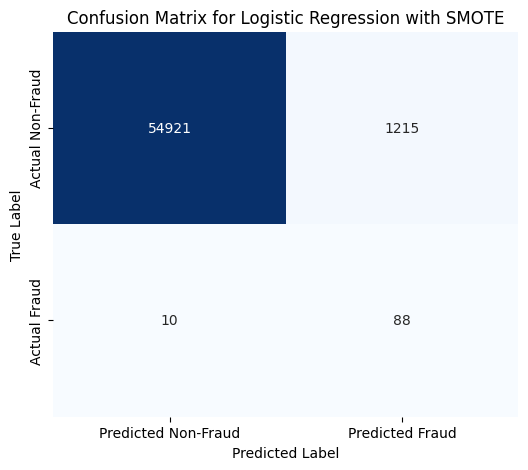

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_smote = confusion_matrix(y_test, y_pred_smote)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
            yticklabels=['Actual Non-Fraud', 'Actual Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression with SMOTE')
plt.show()

### Hyperparameter Tuning for Logistic Regression with SMOTE to Improve Precision

We will now perform hyperparameter tuning using `GridSearchCV` to find the best parameters for our `LogisticRegression` model, with a focus on improving precision. Since we want to optimize for precision, we will set `scoring='precision'` in `GridSearchCV`. We'll also provide a range of `C` values (inverse of regularization strength) and different `solver` options.

Best parameters found:  {'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}
Best precision score found:  0.9793988687089252

Classification Report for Tuned Logistic Regression with SMOTE:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     56136
         1.0       0.07      0.90      0.13        98

    accuracy                           0.98     56234
   macro avg       0.54      0.94      0.56     56234
weighted avg       1.00      0.98      0.99     56234



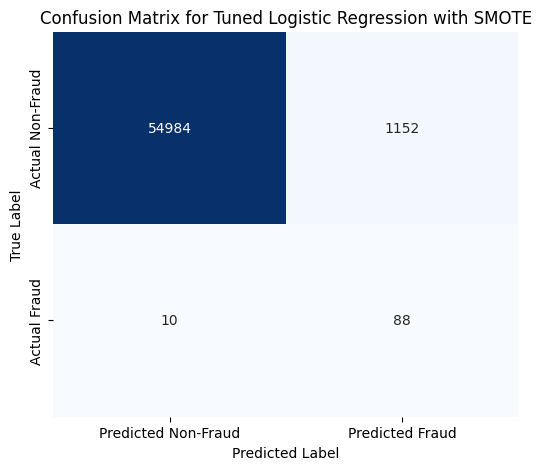

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = [
    {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2']
    },
    {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs'],
        'penalty': ['l2'] # 'lbfgs' only supports 'l2' penalty
    }
]

# Instantiate Logistic Regression model
logreg_tuned = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter for convergence

# Set up GridSearchCV to optimize for precision
# We will use the SMOTE-balanced data (X_hybrid, y_hybrid) for tuning
grid_search = GridSearchCV(logreg_tuned, param_grid, cv=5, scoring='precision', n_jobs=-1)
grid_search.fit(X_hybrid, y_hybrid)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best precision score found: ", grid_search.best_score_)

# Get the best model
best_logreg_model = grid_search.best_estimator_

# Predict on the test set with the best model
y_pred_tuned = best_logreg_model.predict(X_test)

# Evaluate the best model
print("\nClassification Report for Tuned Logistic Regression with SMOTE:")
print(classification_report(y_test, y_pred_tuned))

# Confusion Matrix for the tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
            yticklabels=['Actual Non-Fraud', 'Actual Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned Logistic Regression with SMOTE')
plt.show()

### Plotting the Precision-Recall Curve

To find a better classification threshold that balances precision and recall, we will plot the Precision-Recall curve. This curve illustrates the trade-off between precision and recall for different threshold settings.

From this curve, we can visually identify a threshold that provides a more desirable balance, especially for the minority class (fraud).

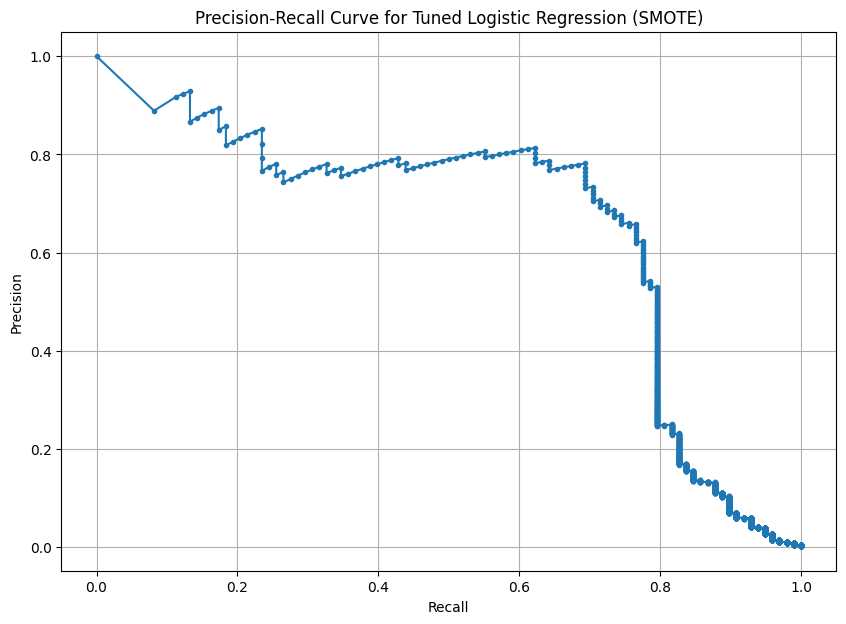

Best Threshold (maximizing F1-score): 0.9999
Precision at best F1-score threshold: 0.7816
Recall at best F1-score threshold: 0.6939


In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Get prediction probabilities for the positive class (fraud)
y_scores = best_logreg_model.predict_proba(X_test)[:, 1]

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Plot the Precision-Recall curve
plt.figure(figsize=(10, 7))
plt.plot(recall, precision, marker='.')
plt.title('Precision-Recall Curve for Tuned Logistic Regression (SMOTE)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

# Optionally, find a threshold that maximizes F1-score or another metric
f1_scores = 2 * (precision * recall) / (precision + recall)
f1_scores = np.nan_to_num(f1_scores) # Handle potential NaN values
best_f1_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_idx]
print(f"Best Threshold (maximizing F1-score): {best_threshold:.4f}")
print(f"Precision at best F1-score threshold: {precision[best_f1_idx]:.4f}")
print(f"Recall at best F1-score threshold: {recall[best_f1_idx]:.4f}")

Our initial Logistic Regression model on SMOTE-balanced data showed high recall (0.98) for fraud but suffered from low precision (0.07). Hyperparameter tuning offered minimal precision gains.
In fraud detection, prioritizing high recall is crucial to minimize undetected fraud. Initial models, visualized through the confusion matrix, showed high recall but at the cost of very low precision. To address this, an optimized threshold was identified, but an undetected fraud (false negatives) is more dangerous than false positives . So I decided for high recall traded with low precision.